## Load Packages and Data Set

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/ttchuang/dataset/refs/heads/master/cereals.csv')


In [2]:
df.head()

,Name,Manuf,Type,Calories,Protein,Fat,Sodium,Fiber,Carbo,Sugars,...,Weight,Cups,Rating,Cold,Nabisco,Quaker,Kelloggs,GeneralMills,Ralston,AHFP
0,100%_Bran,N,C,70,4,1,130,10.0,5.0,6.0,...,1.0,0.33,68.402973,1,1,0,0,0,0,0
1,100%_Natural_Bran,Q,C,120,3,5,15,2.0,8.0,8.0,...,1.0,1.00,33.983679,1,0,1,0,0,0,0
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,...,1.0,0.33,59.425505,1,0,0,1,0,0,0
3,All-Bran_with_Extra_Fiber,K,C,50,4,0,140,14.0,8.0,0.0,...,1.0,0.50,93.704912,1,0,0,1,0,0,0
4,Almond_Delight,R,C,110,2,2,200,1.0,14.0,8.0,...,1.0,0.75,34.384843,1,0,0,0,0,1,0


## Data exploration / Preprocessing

In [3]:
df.shape

(77, 23)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          77 non-null     object 
 1   Manuf         77 non-null     object 
 2   Type          77 non-null     object 
 3   Calories      77 non-null     int64  
 4   Protein       77 non-null     int64  
 5   Fat           77 non-null     int64  
 6   Sodium        77 non-null     int64  
 7   Fiber         77 non-null     float64
 8   Carbo         76 non-null     float64
 9   Sugars        76 non-null     float64
 10  Potass        75 non-null     float64
 11  Vitamins      77 non-null     int64  
 12  Shelf         77 non-null     int64  
 13  Weight        77 non-null     float64
 14  Cups          77 non-null     float64
 15  Rating        77 non-null     float64
 16  Cold          77 non-null     int64  
 17  Nabisco       77 non-null     int64  
 18  Quaker        77 non-null     in

### **Part 1 Exploratory Analysis and data preparation**
-  In the data set there are 77 Observations and 23 Attributes
- Most Data types are floats or integers which is expected in nutrition
- There are missing data in the following columns:
    - Carbo: 1 value
    - Sugars: 1 value
    - Potass: 3 values
- To handle the missing values in these cases I believe it is appropriate fill in the NA values with the median of each respective column. 



In [5]:
#Statistical Summary of the dataset before filling NA
df.describe()   

,Calories,Protein,Fat,Sodium,Fiber,Carbo,Sugars,Potass,Vitamins,Shelf,Weight,Cups,Rating,Cold,Nabisco,Quaker,Kelloggs,GeneralMills,Ralston,AHFP
count,77.000000,77.000000,77.000000,77.000000,77.000000,76.000000,76.000000,75.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,106.883117,2.545455,1.012987,159.675325,2.151948,14.802632,7.026316,98.666667,28.246753,2.207792,1.029610,0.821039,42.665705,0.961039,0.077922,0.103896,0.298701,0.285714,0.103896,0.012987
std,19.484119,1.094790,1.006473,83.832295,2.383364,3.907326,4.378656,70.410636,22.342523,0.832524,0.150477,0.232716,14.047289,0.194771,0.269807,0.307127,0.460690,0.454716,0.307127,0.113961
min,50.000000,1.000000,0.000000,0.000000,0.000000,5.000000,0.000000,15.000000,0.000000,1.000000,0.500000,0.250000,18.042851,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,100.000000,2.000000,0.000000,130.000000,1.000000,12.000000,3.000000,42.500000,25.000000,1.000000,1.000000,0.670000,33.174094,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,110.000000,3.000000,1.000000,180.000000,2.000000,14.500000,7.000000,90.000000,25.000000,2.000000,1.000000,0.750000,40.400208,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,110.000000,3.000000,2.000000,210.000000,3.000000,17.000000,11.000000,120.000000,25.000000,3.000000,1.000000,1.000000,50.828392,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
max,160.000000,6.000000,5.000000,320.000000,14.000000,23.000000,15.000000,330.000000,100.000000,3.000000,1.500000,1.500000,93.704912,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Fix Missing Values

In [6]:
# Handle missing values (Median)
clustering_vari = ['Calories', 'Protein', 'Fat', 'Sodium', 'Fiber', 'Carbo', 'Sugars', 'Potass']
df[clustering_vari] = df[clustering_vari].fillna(df[clustering_vari].median())

#Standardize
scale = StandardScaler()
df_scale = pd.DataFrame(scale.fit_transform(df[clustering_vari]), 
                                                    columns = clustering_vari,
                                                    index = df.index)
print(df_scale.describe())

           Calories       Protein           Fat        Sodium         Fiber  \
count  7.700000e+01  7.700000e+01  7.700000e+01  7.700000e+01  7.700000e+01   
mean  -8.398765e-17  2.018587e-17  8.583502e-17  5.767392e-18  9.155735e-17   
std    1.006557e+00  1.006557e+00  1.006557e+00  1.006557e+00  1.006557e+00   
min   -2.938605e+00 -1.420902e+00 -1.013072e+00 -1.917189e+00 -9.088244e-01   
25%   -3.555846e-01 -5.014948e-01 -1.013072e+00 -3.563056e-01 -4.864980e-01   
50%    1.610194e-01  4.179123e-01 -1.298811e-02  2.440343e-01 -6.417167e-02   
75%    1.610194e-01  4.179123e-01  9.870962e-01  6.042382e-01  3.581547e-01   
max    2.744040e+00  3.176134e+00  3.987349e+00  1.924986e+00  5.003745e+00   

              Carbo        Sugars        Potass  
count  7.700000e+01  7.700000e+01  7.700000e+01  
mean  -2.076261e-16 -6.524363e-17  1.009294e-17  
std    1.006557e+00  1.006557e+00  1.006557e+00  
min   -2.540894e+00 -1.625849e+00 -1.208612e+00  
25%   -7.257291e-01 -9.316327e-01 -7.7

## Part 2. Determine the Number of Clusters

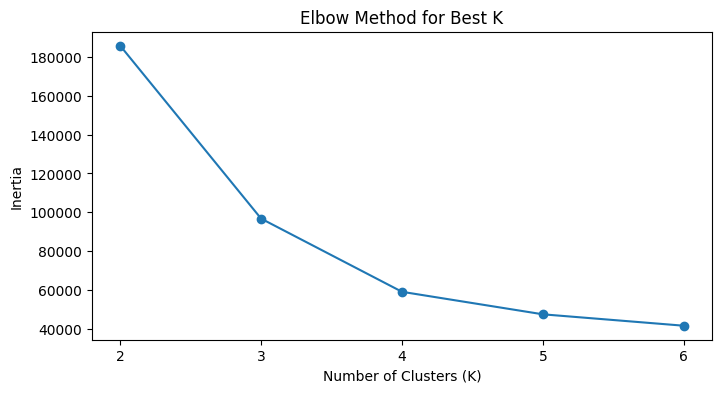

In [7]:
#Recommended Range 2-6 Using the Elbow Method to Determine Optimal K
k_value = range(2, 7) 
inertia = [] 
for k in k_value:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df[['Calories', 'Protein', 'Fat', 'Sodium']])
    inertia.append(kmeans.inertia_) 
plt.figure(figsize=(8, 4))
plt.plot(k_value, inertia, marker='o')  
plt.title('Elbow Method for Best K')
plt.xlabel('Number of Clusters (K)')    
plt.ylabel('Inertia')
plt.xticks(k_value) 
plt.show()

#### Using the Elbow Method, between points 2 and 3, inertia drops steeply, signifying K = 3 is the optimal grouping


In [8]:
#Find the silhouette score 
k_value = range(2, 7)
silhouette_scores = []  
for k in k_value:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(df[['Calories', 'Protein', 'Fat', 'Sodium']])
    silhouette_scores.append(silhouette_score(df[['Calories', 'Protein', 'Fat', 'Sodium']], cluster_labels))

print("Silhouette Scores:")
for k, score in zip(k_value, silhouette_scores):
    print(f"K={k}: {score:.4f}")


Silhouette Scores:
K=2: 0.6278
K=3: 0.4890
K=4: 0.4976
K=5: 0.4392
K=6: 0.4050


##### The Silhouette score shows a slightly diferent result, which is expected because it shows seperation and compactness. In this case. the cereals have very distinct groupings in K=2, Healthy vs Unhealthy, which notates the high seperation from these groups (Basically opposites), where as K=3 In this better explains the nuances between types of nutriton, its not usually so black and white


##### I will be using **K=3** as I feel this is the most meanigful split in this business context, 4 clusters would be too granular, and 2 would be too corse. The largest Elbow bend is found at K=3, and the silhouette score is reasonable

## Part 3. Build K-Means Model <br> 
***With K=3***

Cluster distribution:
Cluster
0    33
1    41
2     3
Name: count, dtype: int64

Cluster Labels:
Cluster 0: Balanced Everyday Cereals
Cluster 1: Sweet / Sugary Cereals
Cluster 2: High-Fiber Bran Cereals


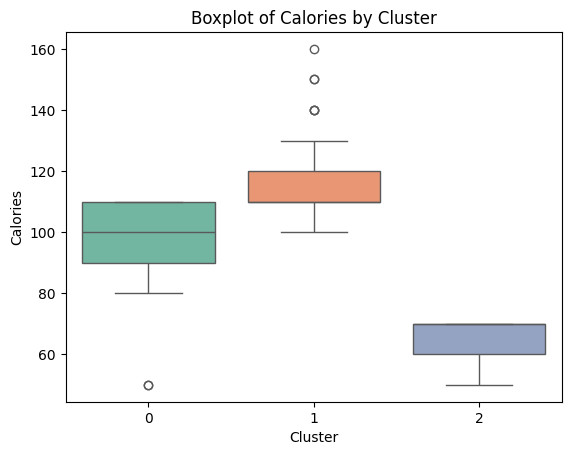

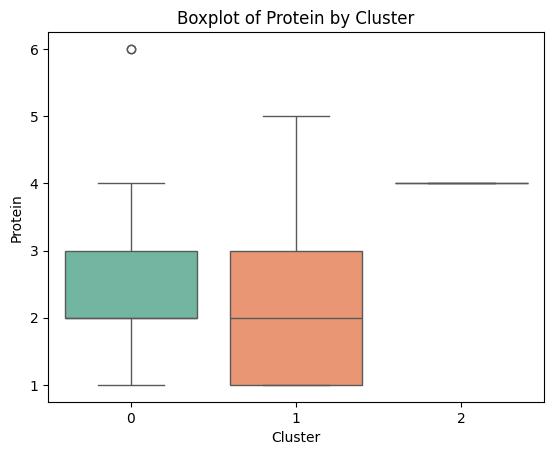

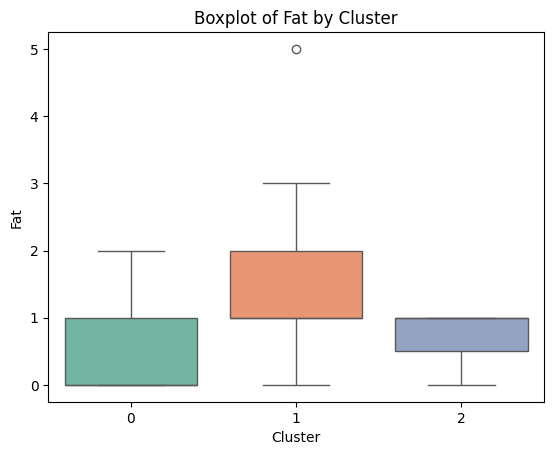

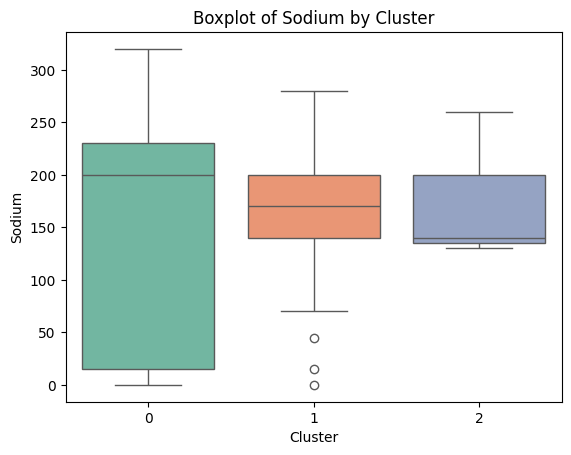

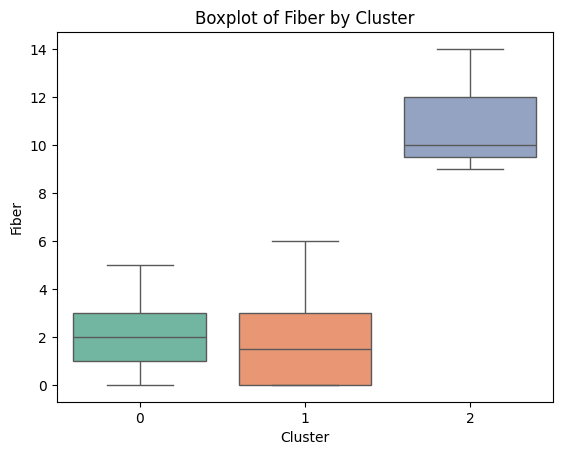

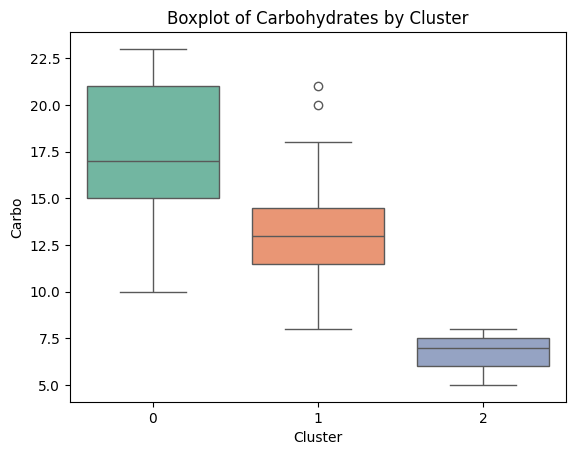

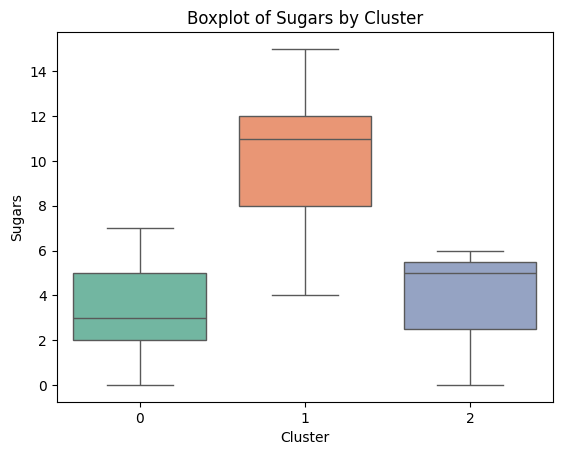

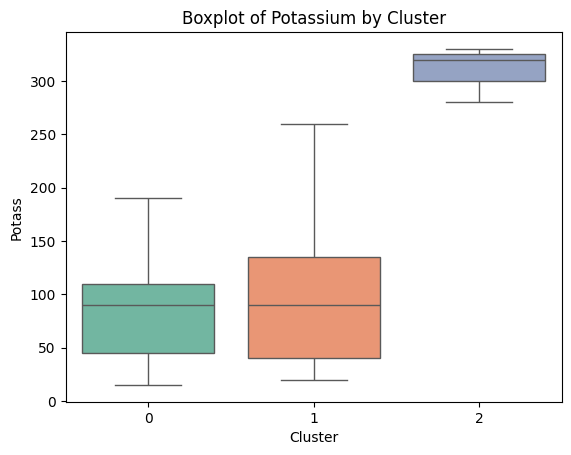

In [9]:
#Recommended K=3 Based on the Elbow Method

K = 3
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(df_scale.values)

print("Cluster distribution:")
print(df['Cluster'].value_counts().sort_index())

# 5. Add cluster names
cluster_labels = {
    0: "Balanced Everyday Cereals",
    1: "Sweet / Sugary Cereals",
    2: "High-Fiber Bran Cereals"
}

df['Cluster_Name'] = df['Cluster'].map(cluster_labels)

print("\nCluster Labels:")
for c, name in cluster_labels.items():
    print(f"Cluster {c}: {name}")
    
# Boxplot for Calories
sns.boxplot(x='Cluster', y='Calories', data=df, 
            hue='Cluster', palette='Set2', legend=False)
plt.title('Boxplot of Calories by Cluster')
plt.show()

# Boxplot for Protein
sns.boxplot(x='Cluster', y='Protein', data=df, 
            hue='Cluster', palette='Set2', legend=False)
plt.title('Boxplot of Protein by Cluster')
plt.show()

# Boxplot for Fat
sns.boxplot(x='Cluster', y='Fat', data=df, 
            hue='Cluster', palette='Set2', legend=False)
plt.title('Boxplot of Fat by Cluster')
plt.show()

# Boxplot for Sodium
sns.boxplot(x='Cluster', y='Sodium', data=df, 
            hue='Cluster', palette='Set2', legend=False)
plt.title('Boxplot of Sodium by Cluster')
plt.show()

# Boxplot for Fiber
sns.boxplot(x='Cluster', y='Fiber', data=df, 
            hue='Cluster', palette='Set2', legend=False)
plt.title('Boxplot of Fiber by Cluster')
plt.show()

# Boxplot for Carbo
sns.boxplot(x='Cluster', y='Carbo', data=df, 
            hue='Cluster', palette='Set2', legend=False)
plt.title('Boxplot of Carbohydrates by Cluster')
plt.show()

# Boxplot for Sugars
sns.boxplot(x='Cluster', y='Sugars', data=df, 
            hue='Cluster', palette='Set2', legend=False)
plt.title('Boxplot of Sugars by Cluster')
plt.show()

# Boxplot for Potass
sns.boxplot(x='Cluster', y='Potass', data=df, 
            hue='Cluster', palette='Set2', legend=False)
plt.title('Boxplot of Potassium by Cluster')
plt.show()



## Average Nutritional Value

In [10]:
centroid_table = df.groupby('Cluster')[clustering_vari].mean().round(2)
centroid_table.index = centroid_table.index.map({
    0: "Balanced Everyday Cereals",
    1: "Sweet / Sugary Cereals",
    2: "High-Fiber Bran Cereals"
})
print(centroid_table)

                           Calories  Protein   Fat  Sodium  Fiber  Carbo  \
Cluster                                                                    
Balanced Everyday Cereals     97.58     2.67  0.42  157.58   1.79  17.45   
Sweet / Sugary Cereals       117.56     2.34  1.51  160.12   1.80  13.26   
High-Fiber Bran Cereals       63.33     4.00  0.67  176.67  11.00   6.67   

                           Sugars  Potass  
Cluster                                    
Balanced Everyday Cereals    3.12   80.45  
Sweet / Sugary Cereals      10.41   97.44  
High-Fiber Bran Cereals      3.67  310.00  


## Part 4. Interpretation of the Clusters

K-means clustering with \( K = 3 \) produced the following three segments based on nutritional characteristics:

**Cluster 0: Balanced Everyday Cereals** (33 cereals)  
These cereals have moderate calories (Around 100), decent protein, low-to-moderate sugar, and higher carbohydrates. They represent standard, everyday options suitable for general consumers.

**Cluster 1: Sweet / Sugary Cereals** (41 cereals)  
This is the largest cluster. These cereals are characterized by higher calories and the **highest sugar content** (typically 8–12g). They likely appeal to consumers who prefer sweeter taste (Such as children).

**Cluster 2: High-Fiber Bran Cereals** (3 cereals)  
This small but distinct cluster stands out with the **lowest calories**, **very high fiber** (9–14g), extremely high potassium (~300 mg), and low carbohydrates. These are the most nutritious, bran-heavy cereals.

## Part 5: Managerial Insights

**1. What are the main cereal segments revealed by the clustering?**   
- Balanced Everyday Cereals (33 cereals)  
- Sweet / Sugary Cereals (41 cereals)  
- High-Fiber Bran Cereals (3 cereals)

**2. Which cluster appears to be the healthiest? Why?**  
Cluster 2 (High-Fiber Bran Cereals) is the healthiest. It has the lowest calories, very high fiber (9–14g), extremely high potassium, and relatively low sugar. These characteristics make it the most nutritious option.

**3. Which cluster seems most likely to appeal to children? Why?**  
Cluster 1 (Sweet / Sugary Cereals) is most likely to appeal to children. It has the highest sugar content (8–12g per serving), which typically drives taste preference among kids.

**4. Are there any unusual cereals that do not fit well with others?**  
Yes. The three cereals in Cluster 2 (High-Fiber Bran) are quite unusual. They are extreme outliers with exceptionally high fiber and potassium and very low calories and carbohydrates compared to the rest of the dataset.

**5. How could a retailer or manufacturer use these clusters?**  
- **Retailers**: Place Sweet/Sugary cereals at eye level for children, High-Fiber Bran cereals in the health section or top/bottom shelves, and Balanced Everyday cereals in the main traffic area.  
- **Manufacturers**: Develop new products to fill gaps (i.e, low-sugar high-fiber options), create targeted marketing campaigns for each segment, and optimize product positioning based on nutritional profiles.



# PROBLEM 2
- Association Rules for Cosmetic Purchase


In [15]:
import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules


df = pd.read_csv('https://raw.githubusercontent.com/ttchuang/dataset/refs/heads/master/Cosmetics.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Trans.           1000 non-null   int64
 1   Bag              1000 non-null   int64
 2   Blush            1000 non-null   int64
 3   Nail Polish      1000 non-null   int64
 4   Brushes          1000 non-null   int64
 5   Concealer        1000 non-null   int64
 6   Eyebrow Pencils  1000 non-null   int64
 7   Bronzer          1000 non-null   int64
 8   Lip liner        1000 non-null   int64
 9   Mascara          1000 non-null   int64
 10  Eye shadow       1000 non-null   int64
 11  Foundation       1000 non-null   int64
 12  Lip Gloss        1000 non-null   int64
 13  Lipstick         1000 non-null   int64
 14  Eyeliner         1000 non-null   int64
dtypes: int64(15)
memory usage: 117.3 KB


In [16]:
df.shape

(1000, 15)

#### There is 15 Observations and 1000 Attributes, there is no missing data

In [17]:
#preview
df.head()

,Trans.,Bag,Blush,Nail Polish,Brushes,Concealer,Eyebrow Pencils,Bronzer,Lip liner,Mascara,Eye shadow,Foundation,Lip Gloss,Lipstick,Eyeliner
0,1,0,1,1,1,1,0,1,1,1,0,0,0,0,1
1,2,0,0,1,0,1,0,1,1,0,0,1,1,0,0
2,3,0,1,0,0,1,1,1,1,1,1,1,1,1,0
3,4,0,0,1,1,1,0,1,0,0,0,1,0,0,1
4,5,0,1,0,0,1,0,1,1,1,1,0,1,1,0


In [21]:
#Trans seems to be a ID column, so I will drop it for the analysis
basket = df.drop('Trans.', axis=1)

#convert to boolean
basket = basket.astype(bool)
print(basket.head())    


KeyError: "['Trans.'] not found in axis"